# 008 Spread Analysis

Цель: понять распределение спреда и когда сигналы надёжнее.

Фичи:
- spread = ask_px_01 - bid_px_01
- volatility proxy: rolling std of mid_price diff (1s window = 10 rows)

Дополнительно:
- spread vs volatility
- spread regime: small vs large (median split)
- сравнение предиктивности imbalance в разных режимах

Структура:
1. Load data
2. Compute feature
3. Build target (200ms)
4. Basic statistics
5. Distribution plots
6. Relationship to future price (binning)
7. Time series (downsampled)
8. Correlation analysis
9. Extreme events analysis


In [1]:
# 1. Load data
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = None
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "pyproject.toml").exists() and (p / "research").is_dir():
        sys.path.insert(0, str(p))
        root = p
        break

root = root or Path.cwd()
data_dir = root / "data" / "reconstructed"

In [2]:
parquet_path = data_dir / "BTC-USDT-SWAP" / "grid100ms" / "2026-03-04" / (
    "book_grid100ms_BTC-USDT-SWAP_2026-03-04_10-00-00__2026-03-04_11-00-00.parquet"
)
if not parquet_path.exists():
    found = sorted(data_dir.rglob("*.parquet"))
    parquet_path = found[0] if found else parquet_path
    if found:
        print("Default parquet not found, loading:", parquet_path)

df = pd.read_parquet(parquet_path)
df.head()

,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-04 10:00:00+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.9,0.02
1,2026-03-04 10:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.71,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.4,0.70
2,2026-03-04 10:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,333.47,71492.3,0.01,...,71494.9,0.73,71495.0,0.01,71495.3,0.70,71496.0,0.78,71496.2,0.70
3,2026-03-04 10:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,337.18,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71495.5,0.70,71496.0,0.08,71496.3,0.03
4,2026-03-04 10:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,353.48,71492.3,0.01,...,71495.0,0.01,71496.0,0.02,71496.9,0.02,71497.0,8.73,71497.3,0.30


In [3]:
# 1 hour slice
_df = df.copy()
_df["ts_event"] = pd.to_datetime(_df["ts_event"], utc=True)
_df = _df.sort_values("ts_event").reset_index(drop=True)
start_ts = _df["ts_event"].min()
end_ts = start_ts + pd.Timedelta(hours=1)
_df = _df[_df["ts_event"].between(start_ts, end_ts)].reset_index(drop=True)
print("Rows:", len(_df))
print("Range:", _df["ts_event"].min(), "..", _df["ts_event"].max())

Rows: 36001
Range: 2026-03-04 10:00:00+00:00 .. 2026-03-04 11:00:00+00:00


In [4]:
# 2. Compute features
_df["mid_price"] = (_df["bid_px_01"] + _df["ask_px_01"]) / 2
_df["spread"] = _df["ask_px_01"] - _df["bid_px_01"]

# volatility proxy: 1s rolling std of mid diff (10 rows)
_df["mid_diff"] = _df["mid_price"].diff()
_df["vol_1s"] = _df["mid_diff"].rolling(10).std().fillna(0)

# imbalance (L1) for predictability comparison
_denom = (_df["bid_sz_01"] + _df["ask_sz_01"]).replace(0, np.nan)
_df["imbalance_l1"] = ((_df["bid_sz_01"] - _df["ask_sz_01"]) / _denom).fillna(0)

_df[["ts_event", "spread", "vol_1s", "imbalance_l1"]].head()

,ts_event,spread,vol_1s,imbalance_l1
0,2026-03-04 10:00:00+00:00,0.1,0.0,0.510785
1,2026-03-04 10:00:00.100000+00:00,0.1,0.0,0.510785
2,2026-03-04 10:00:00.200000+00:00,0.1,0.0,0.212662
3,2026-03-04 10:00:00.300000+00:00,0.1,0.0,0.219480
4,2026-03-04 10:00:00.400000+00:00,0.1,0.0,0.954116


In [5]:
# 3. Target: 200ms future mid
_df["future_mid"] = _df["mid_price"].shift(-2)
_df["delta"] = _df["future_mid"] - _df["mid_price"]
_df["target"] = np.sign(_df["delta"]).astype("Int64")

_df2 = _df.dropna(subset=["future_mid"]).reset_index(drop=True)
print("Rows after shift:", len(_df2))

Rows after shift: 35999


spread
mean: 0.1022667296319094
std: 0.1015348398756855
min: 0.09999999999126885 | max: 9.099999999991269
% positive: 100.0
% negative: 0.0


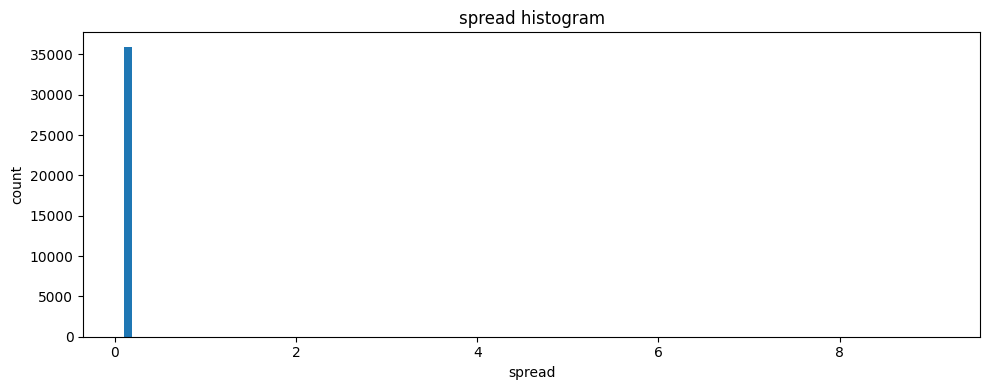

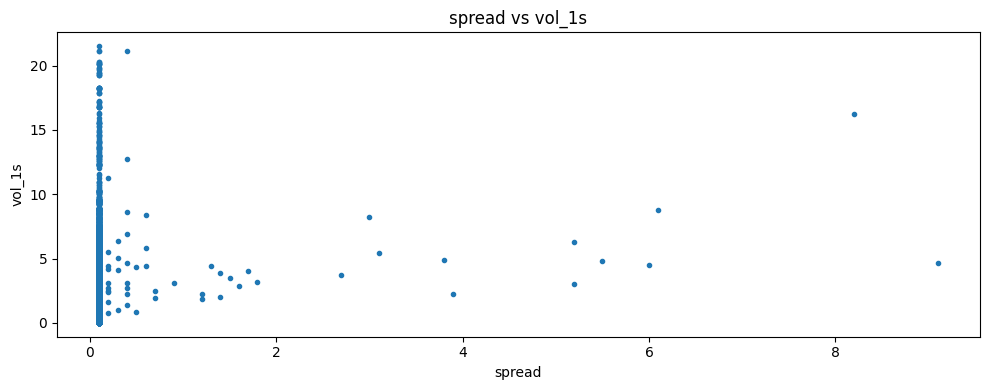

In [6]:
# 4. Basic statistics
s = _df2["spread"].dropna()
print("spread")
print("mean:", s.mean())
print("std:", s.std())
print("min:", s.min(), "| max:", s.max())
print("% positive:", (s > 0).mean() * 100)
print("% negative:", (s < 0).mean() * 100)

# 5. Distribution plots
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(s.values, bins=100)
ax.set_title("spread histogram")
ax.set_xlabel("spread")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

# spread vs volatility
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(_df2["spread"].values, _df2["vol_1s"].values, linestyle="", marker=".")
ax.set_title("spread vs vol_1s")
ax.set_xlabel("spread")
ax.set_ylabel("vol_1s")
plt.tight_layout()
plt.show()

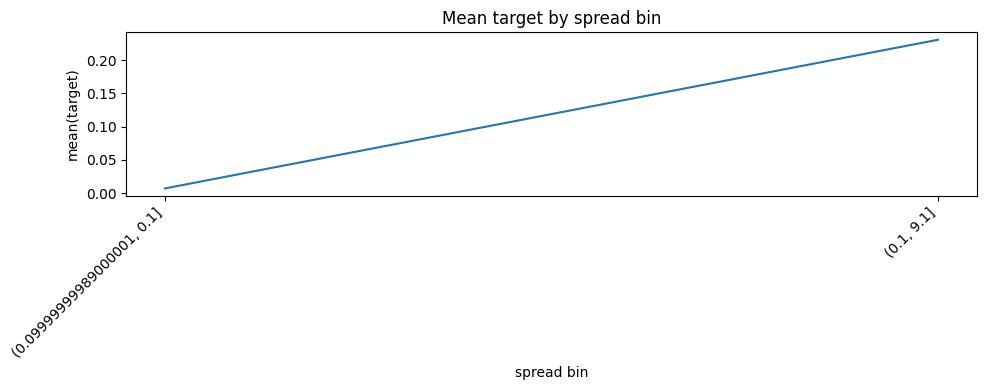

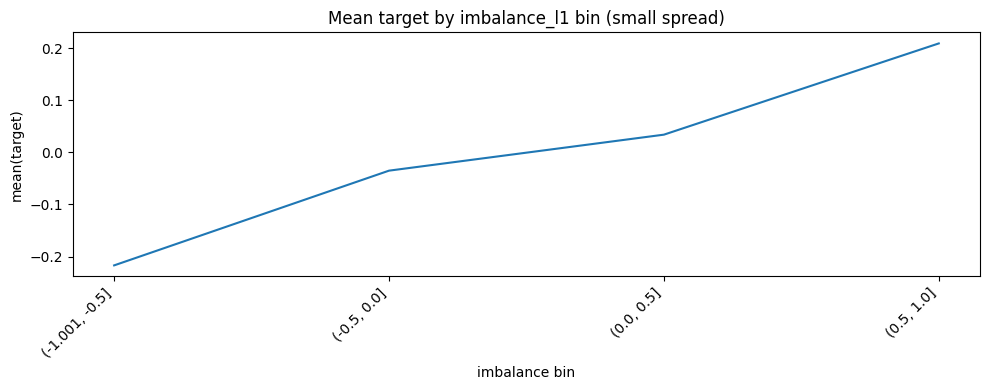

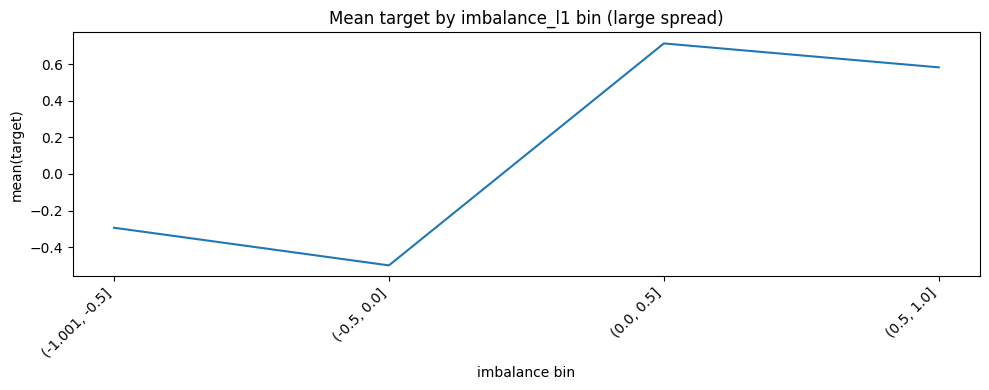

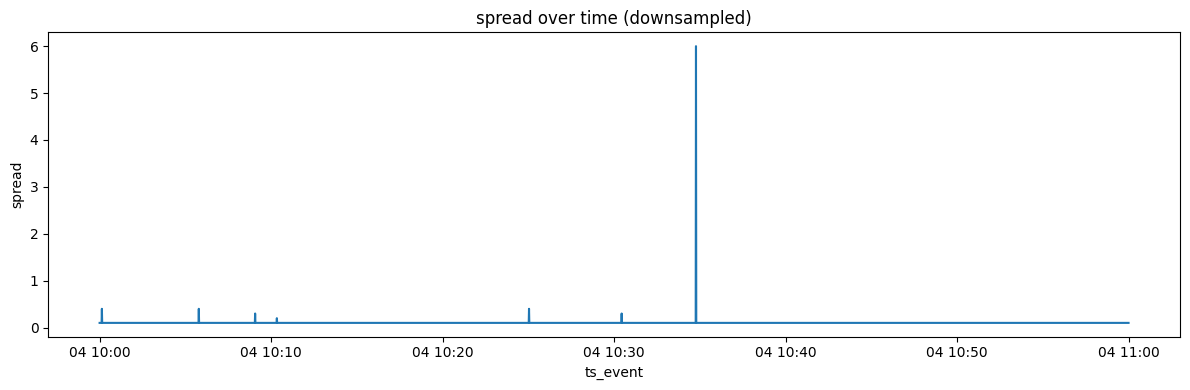

Correlation spread vs delta: -0.004003985729821833
Correlation spread vs vol_1s: 0.05342087454810769

Extreme spread events (>= 99% quantile)
threshold: 0.10000000000582077
count: 22938
avg delta: 0.0021013165925549827
mean target: 0.009024326445200105


In [7]:
# 6. Relationship to future price (binning)
# Binning spread -> mean target
_df2["spread_bin"] = pd.qcut(_df2["spread"], q=5, duplicates="drop")
mean_target = _df2.groupby("spread_bin", observed=True)["target"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(mean_target)), mean_target.values)
ax.set_title("Mean target by spread bin")
ax.set_xlabel("spread bin")
ax.set_ylabel("mean(target)")
ax.set_xticks(range(len(mean_target)))
ax.set_xticklabels([str(x) for x in mean_target.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Predictability: imbalance->target relationship when spread is small vs large
spread_median = _df2["spread"].median()
small = _df2[_df2["spread"] <= spread_median].copy()
large = _df2[_df2["spread"] > spread_median].copy()

bins_imb = [-1.0, -0.5, 0.0, 0.5, 1.0]
small["imb_bin"] = pd.cut(small["imbalance_l1"], bins=bins_imb, include_lowest=True)
large["imb_bin"] = pd.cut(large["imbalance_l1"], bins=bins_imb, include_lowest=True)

m_small = small.groupby("imb_bin", observed=True)["target"].mean()
m_large = large.groupby("imb_bin", observed=True)["target"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(m_small)), m_small.values)
ax.set_title("Mean target by imbalance_l1 bin (small spread)")
ax.set_xlabel("imbalance bin")
ax.set_ylabel("mean(target)")
ax.set_xticks(range(len(m_small)))
ax.set_xticklabels([str(x) for x in m_small.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(m_large)), m_large.values)
ax.set_title("Mean target by imbalance_l1 bin (large spread)")
ax.set_xlabel("imbalance bin")
ax.set_ylabel("mean(target)")
ax.set_xticks(range(len(m_large)))
ax.set_xticklabels([str(x) for x in m_large.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7. Time series (downsample)
down = _df2.iloc[::10].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(down["ts_event"], down["spread"].values)
ax.set_title("spread over time (downsampled)")
ax.set_xlabel("ts_event")
ax.set_ylabel("spread")
plt.tight_layout()
plt.show()

# 8. Correlation analysis
print("Correlation spread vs delta:", _df2["spread"].corr(_df2["delta"]))
print("Correlation spread vs vol_1s:", _df2["spread"].corr(_df2["vol_1s"]))

# 9. Extreme events analysis
thr = _df2["spread"].quantile(0.99)
ext = _df2[_df2["spread"] >= thr]
print("\nExtreme spread events (>= 99% quantile)")
print("threshold:", thr)
print("count:", len(ext))
print("avg delta:", ext["delta"].mean())
print("mean target:", ext["target"].mean())